# PROYEK DATA MINING

Kelompok 3:

Nurul Hidayati (2304020044)

Iraina mayang Fauni (2304020046)

Athiyah Taqiyyatul Labibah (2304020050)

# Penerapan Algoritma K-Means Clustering dalam Analisis Hasil Pre-Test dan Post-Test untuk Mengelompokkan Kemampuan Belajar Siswa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Pada tahap ini dilakukan import library yang diperlukan dalam penelitian. Library Pandas digunakan untuk membaca dan mengelola data, Matplotlib digunakan untuk visualisasi data, sedangkan Scikit-learn digunakan untuk proses normalisasi data dan implementasi algoritma K-Means Clustering.

In [3]:
#Membaca Dataset
data = pd.read_excel("Nilai PreTest dan PostTest.xlsx")

Dataset yang berisi nilai PreTest dan PostTest siswa dibaca dari file Excel menggunakan library Pandas. Data yang berhasil dibaca kemudian disimpan dalam variabel 'data' untuk digunakan pada tahap selanjutnya.

In [4]:
print(data.head())

   No                      Nama  PreTest  PostTest
0   1            Aldi Kurniawan     16.0      70.0
1   2         Atha Rizki Syakur     25.0      40.0
2   3          Berliana Agustin     50.0     100.0
3   4  Christian Okta Lorensius     40.0      45.0
4   5     Dimas Yofi Kusumo Aji     40.0     100.0


Output berikut menampilkan lima baris pertama dari dataset. Tujuannya adalah untuk memastikan bahwa data berhasil dibaca dengan benar dari file Excel serta memeriksa struktur data yang akan digunakan dalam penelitian.

In [5]:
#Pemeriksaan Missing Value
print(data.isnull().sum())

No          0
Nama        0
PreTest     1
PostTest    1
dtype: int64


Tahap ini bertujuan untuk mengidentifikasi adanya data yang kosong atau tidak lengkap. Data yang tidak lengkap dapat memengaruhi hasil analisis sehingga perlu ditangani sebelum proses clustering dilakukan.

Pada output menunjukkan jumlah data kosong pada setiap kolom. Ditemukan data kosong pada kolom PreTest dan postTest sebanyak masing-masing 1 data. Kemudian karena ditemukan data kosong, maka perlu dilakukan pembersihan data sebelum proses analisis dilakukan.

In [6]:
#Data Cleaning
data = data.dropna()

Data yang memiliki nilai kosong dihapus menggunakan metode 'dropna()'. Proses ini dilakukan untuk memastikan bahwa seluruh data yang digunakan dalam analisis memiliki informasi yang lengkap.

Setelah proses data cleaning dilakukan menggunakan metode 'dropna()', seluruh data kosong berhasil dihapus. Hasil ini menunjukkan bahwa dataset telah siap digunakan untuk tahap analisis berikutnya.

In [7]:
print(data.isnull().sum())

No          0
Nama        0
PreTest     0
PostTest    0
dtype: int64


Tahap ini dilakukan pengecekan ulang untuk mengidentifikasi apakah masih terdapat data kosong atau tidak lengkap.

Pada output diperoleh jumlah data kosong untuk setiap kolom adalah 0. Jadi sudah tidak terdapat data kosong. Sehingga dataset telah siap digunakan untuk tahap analisis berikutnya.

In [8]:
#Perhitungan Gain Score
data['Gain'] = data['PostTest'] - data['PreTest']

Variabel baru berupa Gain Score dibuat untuk mengukur peningkatan hasil belajar siswa. Gain Score dihitung dari selisih antara nilai PostTest dan PreTest.

In [9]:
print(data[['Nama','PreTest','PostTest','Gain']].head())

                       Nama  PreTest  PostTest  Gain
0            Aldi Kurniawan     16.0      70.0  54.0
1         Atha Rizki Syakur     25.0      40.0  15.0
2          Berliana Agustin     50.0     100.0  50.0
3  Christian Okta Lorensius     40.0      45.0   5.0
4     Dimas Yofi Kusumo Aji     40.0     100.0  60.0


Output menampilkan Nama, PreTest, PostTest, dan Gain Score yang diperoleh dari selisih antara nilai PostTest dan PreTest.

In [10]:
#Statistik Deskriptif
print(data[['PreTest','PostTest','Gain']].describe())

         PreTest    PostTest       Gain
count  30.000000   30.000000  30.000000
mean   27.633333   86.833333  59.200000
std    11.357766   17.689045  18.877829
min     7.000000   40.000000   5.000000
25%    20.000000   81.250000  54.250000
50%    25.000000   95.000000  62.500000
75%    39.000000  100.000000  70.750000
max    50.000000  100.000000  93.000000


Analisis statistik deskriptif dilakukan untuk memperoleh gambaran umum data, seperti nilai rata-rata, nilai minimum, nilai maksimum, dan standar deviasi pada setiap variabel yang digunakan.

Output statistik deskriptif memberikan gambaran umum mengenai data yang digunakan. Informasi ini membantu dalam memahami karakteristik data sebelum dilakukan proses clustering.

In [11]:
from sklearn.preprocessing import StandardScaler

X = data[['PreTest','PostTest','Gain']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Variabel yang digunakan dalam proses clustering dipilih yaitu PreTest, PostTest, dan Gain Score, kemudian disimpan ke dalam variabel X. Ketiga variabel tersebut digunakan sebagai dasar dalam proses pengelompokan siswa.

Normalisasi dilakukan menggunakan StandardScaler untuk mengubah data sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Tujuannya agar seluruh variabel memiliki skala yang seimbang. Tahap ini penting agar tidak terdapat variabel yang mendominasi proses clustering akibat memiliki rentang nilai yang lebih besar.

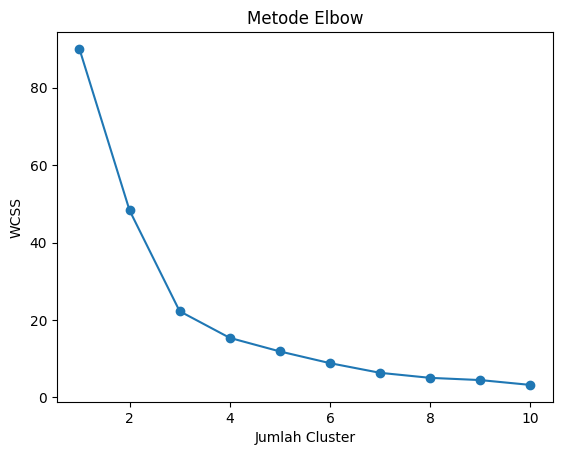

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Metode Elbow')
plt.show()

Metode Elbow digunakan untuk menentukan jumlah cluster yang optimal. Proses ini dilakukan dengan menghitung nilai Within Cluster Sum of Squares (WCSS) pada beberapa jumlah cluster dan mengamati titik siku (elbow) pada grafik yang terbentuk.

Grafik Elbow ditampilkan untuk membantu menentukan jumlah cluster yang paling optimal berdasarkan perubahan nilai WCSS.

pada Output Grafik Elbow menunjukkan hubungan antara jumlah cluster dan nilai Within Cluster Sum of Squares (WCSS). Terlihat adanya penurunan yang cukup signifikan hingga cluster ke-3, kemudian penurunan mulai melandai. Oleh karena itu, jumlah cluster optimal yang digunakan dalam penelitian ini adalah sebanyak 3 cluster.




In [14]:
#Implementasi K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

data['Cluster'] = kmeans.fit_predict(X_scaled)

Setelah diperoleh jumlah cluster optimal, algoritma K-Means diterapkan untuk mengelompokkan siswa berdasarkan nilai PreTest, PostTest, dan Gain Score.

In [15]:
#Hasil Clustering
print(data[['Nama','PreTest','PostTest','Gain','Cluster']])

                              Nama  PreTest  PostTest  Gain  Cluster
0                   Aldi Kurniawan     16.0      70.0  54.0        1
1                Atha Rizki Syakur     25.0      40.0  15.0        2
2                 Berliana Agustin     50.0     100.0  50.0        0
3         Christian Okta Lorensius     40.0      45.0   5.0        2
4            Dimas Yofi Kusumo Aji     40.0     100.0  60.0        0
5                Elisabeth Christy     43.0     100.0  57.0        0
7            Fayrisa Cahyaningtyas     25.0      80.0  55.0        1
8   Gabriell Alviano Putra Senatha     10.0      85.0  75.0        1
9         Gendhis Nathan Kurniawan     22.0     100.0  78.0        1
10              Ibnu Satria Rivano     35.0      75.0  40.0        0
11         Jihan Naura Nur Hanifah     40.0     100.0  60.0        0
12             Kenzie Ibra Niscala     47.0      95.0  48.0        0
13           Leony Putri Anggraini     27.0     100.0  73.0        1
14           Luthfiani Nur Safitri

Setiap siswa diberikan label cluster berdasarkan hasil pengelompokan yang dilakukan oleh algoritma K-Means. Label cluster digunakan untuk mengidentifikasi kelompok siswa dengan karakteristik yang serupa.

Output menunjukkan hasil clustering yang dilakukan menggunakan algoritma K-Means. Setiap siswa memperoleh label cluster yang menunjukkan kelompok tempat siswa tersebut tergabung berdasarkan kemiripan nilai PreTest, PostTest, dan Gain Score.

In [16]:
#Analisis Karakteristik Cluster

print(
    data.groupby('Cluster')[
        ['PreTest','PostTest','Gain']
    ].mean()
)

           PreTest   PostTest       Gain
Cluster                                 
0        41.555556  94.444444  52.888889
1        20.777778  90.555556  69.777778
2        27.000000  41.666667  14.666667


Rata-rata nilai PreTest, PostTest, dan Gain Score dihitung pada setiap cluster untuk mengetahui karakteristik masing-masing kelompok siswa.

Berdasarkan nilai rata-rata setiap cluster, diperoleh karakteristik yang berbeda pada masing-masing kelompok siswa.

- Cluster 0 memiliki rata-rata nilai PreTest dan PostTest yang tinggi, menunjukkan kelompok siswa dengan kemampuan awal dan hasil belajar yang baik.
- Cluster 1 memiliki nilai Gain Score tertinggi, menunjukkan kelompok siswa yang mengalami peningkatan hasil belajar paling signifikan.
- Cluster 2 memiliki nilai Gain Score terendah, menunjukkan kelompok siswa yang masih memerlukan pendampingan lebih lanjut dalam proses pembelajaran.

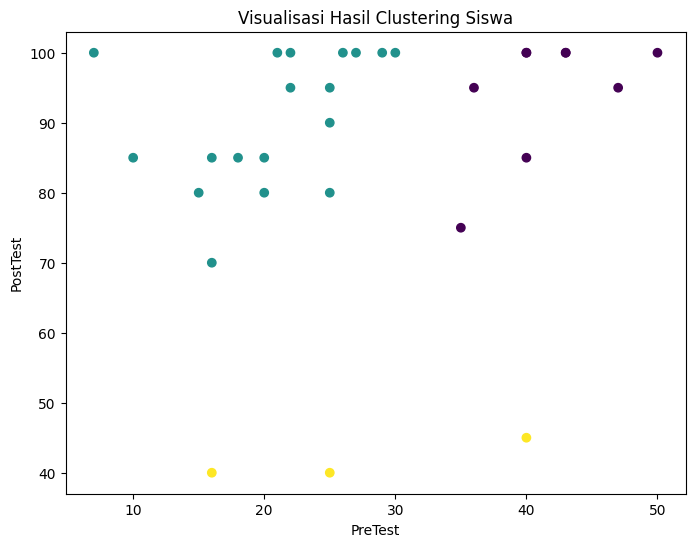

In [17]:
#Visualisasi Hasil Clustering

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    data['PreTest'],
    data['PostTest'],
    c=data['Cluster']
)

plt.xlabel('PreTest')
plt.ylabel('PostTest')
plt.title('Visualisasi Hasil Clustering Siswa')

plt.show()

Scatter plot digunakan untuk memvisualisasikan persebaran siswa berdasarkan nilai PreTest dan PostTest serta menunjukkan hasil pengelompokan yang terbentuk.

Berdasarkan hasil Scatter Plot yang terbentuk menunjukkan visualisasi hasil clustering siswa berdasarkan nilai PreTest dan PostTest. Hasil pengelompokan menunjukkan adanya tiga cluster yang memiliki karakteristik berbeda. Cluster pertama terdiri atas siswa dengan hasil belajar tinggi yang ditunjukkan oleh nilai PostTest yang dominan berada pada rentang 75-100. Cluster kedua didominasi oleh siswa dengan kemampuan awal yang lebih tinggi dan hasil belajar yang baik. Sementara itu, cluster ketiga berisi siswa dengan nilai PostTest yang relatif rendah sehingga terpisah secara jelas dari cluster lainnya. Pemisahan antarcluster yang cukup terlihat menunjukkan bahwa algoritma K-Means mampu mengelompokkan siswa berdasarkan pola kemampuan belajar yang dimiliki.

In [18]:
#Distribusi Anggota Cluster
print(data['Cluster'].value_counts())

Cluster
1    18
0     9
2     3
Name: count, dtype: int64


Jumlah anggota pada setiap cluster dihitung untuk mengetahui persebaran siswa dalam masing-masing kelompok hasil clustering.

Berdasarkan hasil clustering, setiap cluster memiliki jumlah anggota yang berbeda. Hal ini menunjukkan bahwa karakteristik kemampuan belajar siswa tidak tersebar secara merata pada setiap kelompok

In [19]:
#Evaluasi Clustering

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, data['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.5180559089958107


Kualitas hasil clustering dievaluasi menggunakan Silhouette Score. Nilai yang mendekati 1 menunjukkan kualitas cluster yang semakin baik, sedangkan nilai yang mendekati 0 menunjukkan adanya tumpang tindih antarcluster.

Hasil evaluasi menggunakan Silhouette Score menghasilkan nilai sebesar 0,518. Nilai ini menunjukkan bahwa kualitas clustering yang terbentuk tergolong cukup baik karena setiap cluster memiliki tingkat pemisahan yang cukup jelas dan tidak terlalu banyak tumpang tindih dengan cluster lainnya.